   label  type  site_admin  company   blog  location  hireable  \
0  Human  True       False    False  False     False     False   
1  Human  True       False    False   True     False      True   
2  Human  True       False     True   True      True      True   
3    Bot  True       False    False  False      True     False   
4  Human  True       False    False  False     False      True   

                                                 bio  public_repos  \
0                                                NaN            26   
1  I just press the buttons randomly, and the pro...            30   
2         Time is unimportant,\nonly life important.           103   
3                                                NaN            49   
4                                                NaN            11   

   public_gists  followers  following                 created_at  \
0             1          5          1  2011-09-26 17:27:03+00:00   
1             3          9          6  2015-06

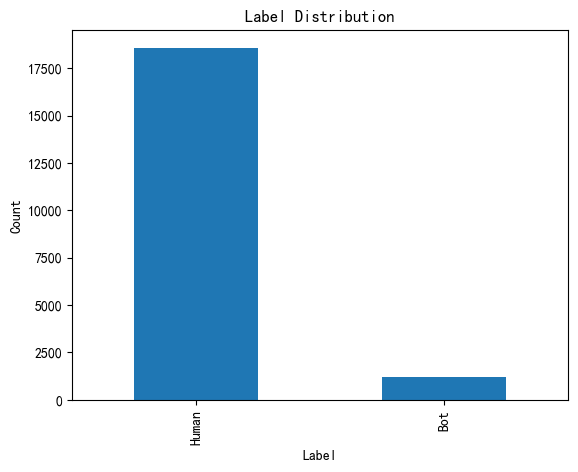

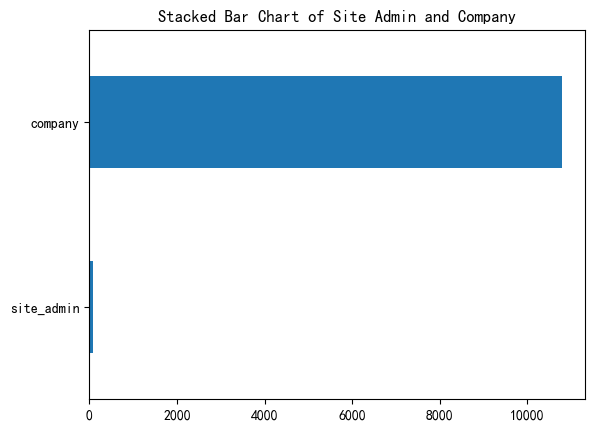

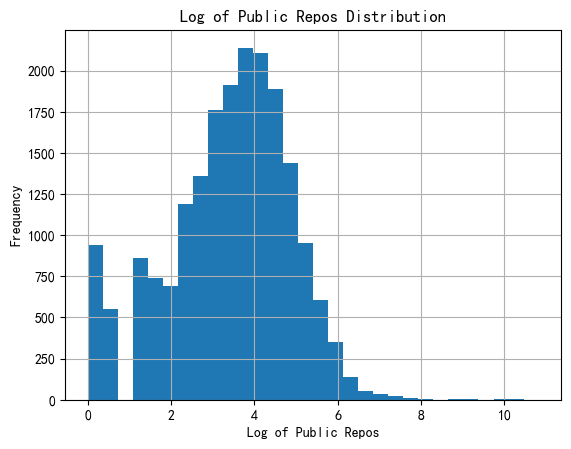

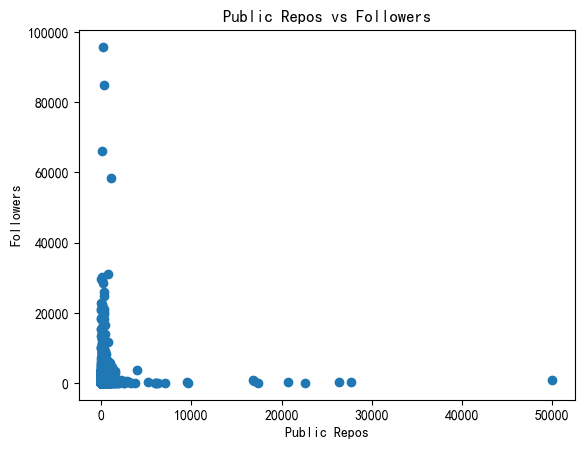

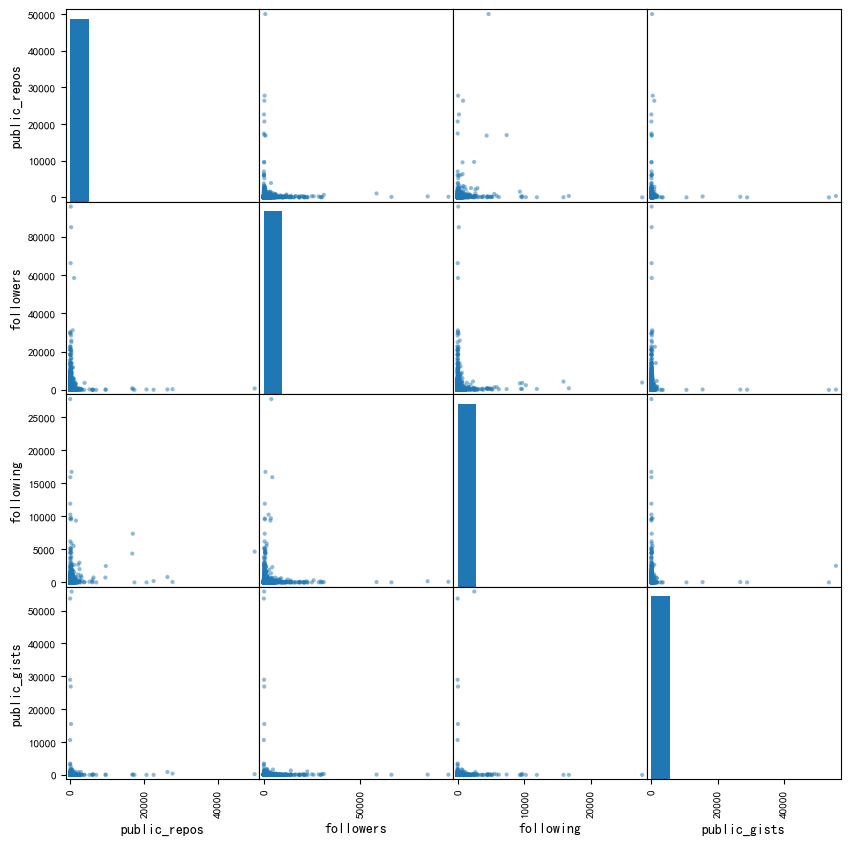

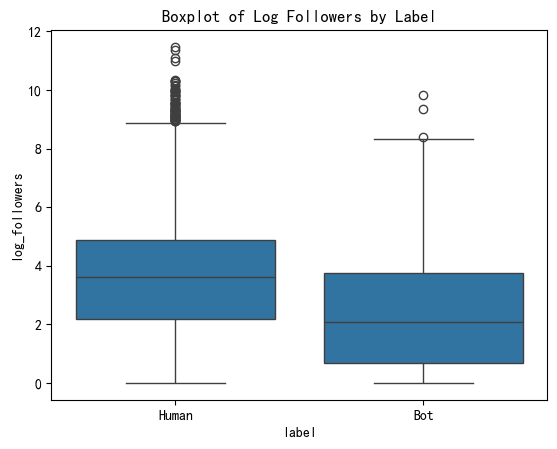

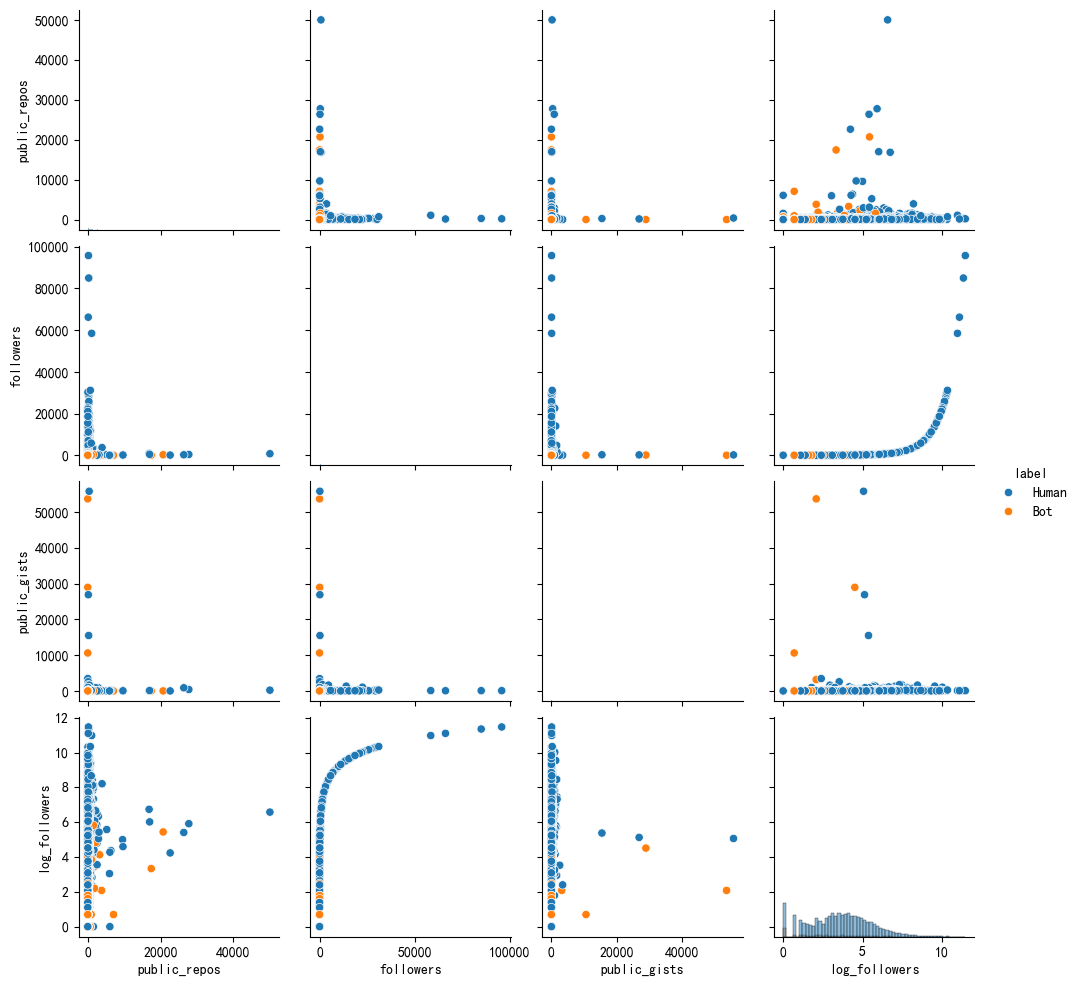

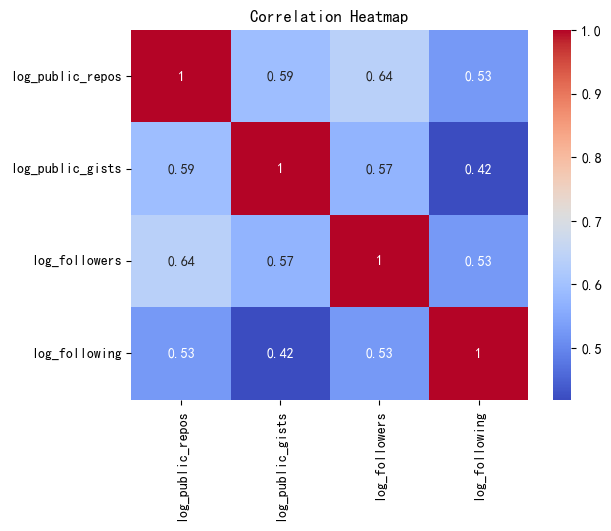

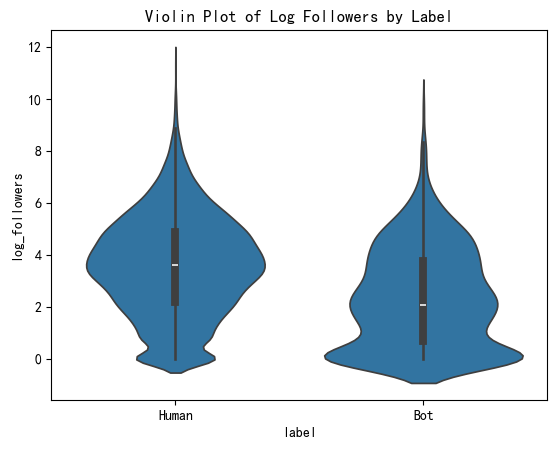

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取数据集
df = pd.read_csv("github_bot_processed_data.csv")

# 2. 数据概览
# 查看前几行
print(df.head())

# 查看数据类型
print(df.info())

# 获取描述性统计信息
print(df.describe())

# 3. 数据格式化处理
# 日期格式化
df['created_at'] = pd.to_datetime(df['created_at'])

# 格式化货币列（如果需要）
# 注意：这里假设'public_repos'不是货币列，请根据实际情况调整
# df['public_repos'] = df['public_repos'].apply(lambda x: f"${x:,.2f}" if isinstance(x, (int, float)) else x)

# 4. 对数变换
log_features = ['public_repos', 'public_gists', 'followers', 'following']
for feature in log_features:
    df[f'log_{feature}'] = pd.to_numeric(df[feature], errors='coerce')
    df[f'log_{feature}'] = np.log1p(df[f'log_{feature}'])  # +1 避免log(0)问题

# 5. 使用Matplotlib绘制图表

## 条形图：展示label列的类别分布
df['label'].value_counts().plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

## 堆积柱状图：展示site_admin和company等布尔特征的分布
df[['site_admin', 'company']].sum().plot(kind='barh', stacked=True)
plt.title('Stacked Bar Chart of Site Admin and Company')
plt.show()

## 直方图：展示log_public_repos的对数变换后的数据分布
df['log_public_repos'].hist(bins=30)
plt.title('Log of Public Repos Distribution')
plt.xlabel('Log of Public Repos')
plt.ylabel('Frequency')
plt.show()

## 散点图：展示public_repos与followers之间的关系
plt.scatter(df['public_repos'], df['followers'])
plt.title('Public Repos vs Followers')
plt.xlabel('Public Repos')
plt.ylabel('Followers')
plt.show()

## 散点矩阵：展示多个数值型特征之间的成对关系
pd.plotting.scatter_matrix(df[['public_repos', 'followers', 'following', 'public_gists']], figsize=(10, 10))
plt.show()

# 6. 使用Seaborn绘制图表

## 箱线图：展示不同label类别下log_followers的分布
sns.boxplot(x='label', y='log_followers', data=df)
plt.title('Boxplot of Log Followers by Label')
plt.show()

## 成对图：展示不同特征之间的成对关系，并根据label分类
sns.pairplot(df[['public_repos', 'followers', 'public_gists', 'log_followers', 'label']], hue='label', diag_kind='hist')
plt.show()

## 热图：展示log_public_repos、log_public_gists、log_followers和log_following等特征之间的相关性
corr = df[['log_public_repos', 'log_public_gists', 'log_followers', 'log_following']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 小提琴图：展示label与log_followers之间的分布差异
sns.violinplot(x='label', y='log_followers', data=df)
plt.title('Violin Plot of Log Followers by Label')
plt.show()

In [9]:

import pandas as pd
from ydata_profiling import ProfileReport  

from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)


profile = ProfileReport(df, title="YData Profiling Report", explorative=True)

profile.to_notebook_iframe()

profile.to_file("your_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]